Accuracy: 0.8197303051809794
Confusion Matrix:
 [[933 103]
 [151 222]]
ROC-AUC: 0.8620040473257631
Custom Accuracy: 0.7764371894960965

Top features:
                            feature    weight
3                     TotalCharges  0.627137
10     InternetService_Fiber optic  0.622950
23             StreamingMovies_Yes  0.230364
21                 StreamingTV_Yes  0.180316
9                MultipleLines_Yes  0.168662
26            PaperlessBilling_Yes  0.163692
28  PaymentMethod_Electronic check  0.150779
0                    SeniorCitizen  0.058427
8   MultipleLines_No phone service  0.034680
17            DeviceProtection_Yes  0.028529

Top risky customers:
       SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
1109       2.284413 -1.284605        1.194408     -0.967944    -1.025166   
365        2.284413 -1.243659        0.963409     -0.936966    -1.025166   
1106       2.284413 -1.284605        0.968394     -0.970952     0.975452   
680       -0.437749 -1.2846

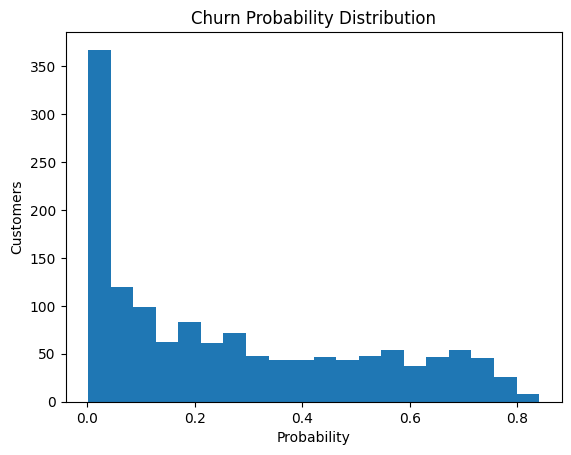

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt




df = pd.read_csv(r"C:\Users\Lenovo\Documents\Downloads\Telco-Customer-Churn.csv")


df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())



X = df.drop("Churn", axis=1)
y = df["Churn"]


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
churn_prob = model.predict_proba(X_test)[:, 1]



print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, churn_prob))


y_pred_custom = (churn_prob > 0.3).astype(int)
print("Custom Accuracy:", accuracy_score(y_test, y_pred_custom))


importance = pd.DataFrame({
    "feature": X.columns,
    "weight": model.coef_[0]
}).sort_values(by="weight", ascending=False)

print("\nTop features:\n", importance.head(10))


results = pd.DataFrame(X_test, columns=X.columns)
results["churn_probability"] = churn_prob

top_risky = results.sort_values(by="churn_probability", ascending=False)

print("\nTop risky customers:\n", top_risky.head(10))



plt.hist(churn_prob, bins=20)
plt.title("Churn Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Customers")
plt.show()